In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [6]:
yearly_df = pd.read_csv("D:\Ftn\Python\LEC_7\yearly_deaths_by_clinic.csv")

In [7]:
yearly_df

,year,births,deaths,clinic
0,1841,3036,237,clinic 1
1,1842,3287,518,clinic 1
2,1843,3060,274,clinic 1
3,1844,3157,260,clinic 1
4,1845,3492,241,clinic 1
5,1846,4010,459,clinic 1
6,1841,2442,86,clinic 2
7,1842,2659,202,clinic 2
8,1843,2739,164,clinic 2
9,1844,2956,68,clinic 2


In [8]:
yearly_df.shape

(12, 4)

In [9]:
yearly_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   year    12 non-null     int64 
 1   births  12 non-null     int64 
 2   deaths  12 non-null     int64 
 3   clinic  12 non-null     object
dtypes: int64(3), object(1)
memory usage: 516.0+ bytes


In [10]:
yearly_df.groupby("clinic") ["deaths"].sum()

clinic
clinic 1    1989
clinic 2     691
Name: deaths, dtype: int64

In [ ]:
The above observation is about the death occuring clinic wise which is more incompare to clininc 1

In [11]:
#To make the analysis easier, we can calculate the proportion of deaths.
yearly_df["Proportion of Deaths"] = yearly_df["deaths"] / yearly_df["births"]
yearly_df

,year,births,deaths,clinic,Proportion of Deaths
0,1841,3036,237,clinic 1,0.078063
1,1842,3287,518,clinic 1,0.157591
2,1843,3060,274,clinic 1,0.089542
3,1844,3157,260,clinic 1,0.082357
4,1845,3492,241,clinic 1,0.069015
5,1846,4010,459,clinic 1,0.114464
6,1841,2442,86,clinic 2,0.035217
7,1842,2659,202,clinic 2,0.075968
8,1843,2739,164,clinic 2,0.059876
9,1844,2956,68,clinic 2,0.023004


In [12]:
#separate the dataset into 2 datasets, one for each clinic
clinic_1 = yearly_df[yearly_df["clinic"] == "clinic 1"]
clinic_2 = yearly_df[yearly_df["clinic"] == "clinic 2"]
    

In [13]:
clinic_1

,year,births,deaths,clinic,Proportion of Deaths
0,1841,3036,237,clinic 1,0.078063
1,1842,3287,518,clinic 1,0.157591
2,1843,3060,274,clinic 1,0.089542
3,1844,3157,260,clinic 1,0.082357
4,1845,3492,241,clinic 1,0.069015
5,1846,4010,459,clinic 1,0.114464


In [14]:
clinic_2

,year,births,deaths,clinic,Proportion of Deaths
6,1841,2442,86,clinic 2,0.035217
7,1842,2659,202,clinic 2,0.075968
8,1843,2739,164,clinic 2,0.059876
9,1844,2956,68,clinic 2,0.023004
10,1845,3241,66,clinic 2,0.020364
11,1846,3754,105,clinic 2,0.027970


Text(0, 0.5, 'Number of Deaths')

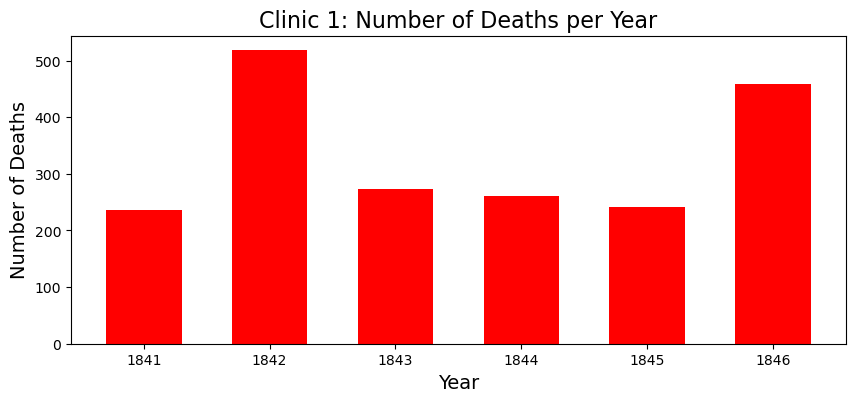

In [15]:
#Visualize the Number of deaths every year in clinic 1
fig,ax = plt.subplots(figsize = (10,4))
plt.bar(clinic_1.year,clinic_1.deaths,width= 0.6, color= "red")
plt.title("Clinic 1: Number of Deaths per Year", fontsize = 16)
plt.xlabel("Year", fontsize = 14)
plt.ylabel("Number of Deaths", fontsize = 14)

Text(0, 0.5, 'Number of Deaths')

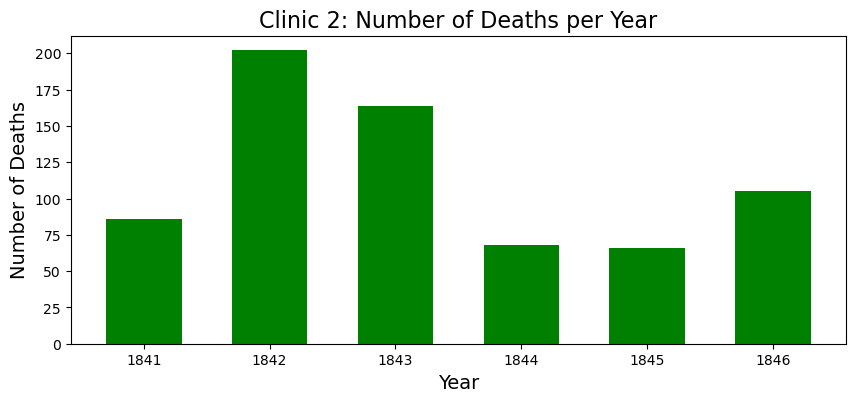

In [16]:
#Visualize the Number of deaths every year in clinic 2
fig,ax = plt.subplots(figsize = (10,4))
plt.bar(clinic_2.year, clinic_2.deaths, width= 0.6, color= "green")
plt.title("Clinic 2: Number of Deaths per Year", fontsize = 16)
plt.xlabel("Year", fontsize = 14)
plt.ylabel("Number of Deaths", fontsize = 14)

In [ ]:
As per the above observation year 1842 has pop-out to be an year with highest number of deaths which is 518 in Clinic 1 and 202 in clinic 2

<Axes: xlabel='year', ylabel='Proportion of Deaths'>

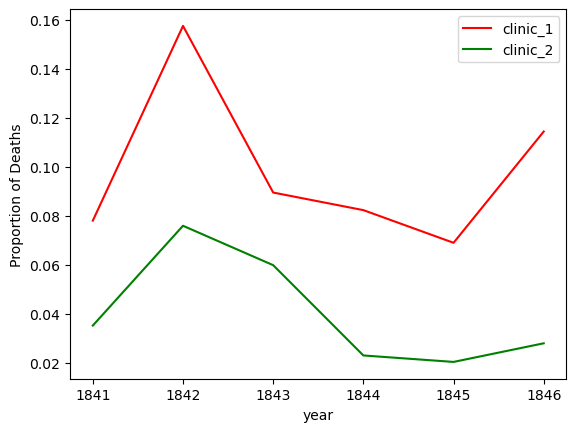

In [17]:
#Plot the proportion of deaths in clinic 1 and 2
ax = clinic_1.plot(x= "year", y= "Proportion of Deaths", label= "clinic_1", color="red")
clinic_2.plot(x= "year",y = "Proportion of Deaths", label = "clinic_2", ax=ax, ylabel= "Proportion of Deaths", color="green")

In [ ]:
The proportion of deaths is consistently higher in Clinic 1 than in Clinic 2. Clinic 1 reaches its highest proportion of approximately 0.16 in 1842, while Clinic 2 remains below 0.08 throughout the period.

In [31]:
#Read the montly dataset
monthly = pd.read_csv("D:\Ftn\Python\LEC_7\monthly_deaths.csv")
monthly.head()

,date,births,deaths
0,1841-01-01,254,37
1,1841-02-01,239,18
2,1841-03-01,277,12
3,1841-04-01,255,4
4,1841-05-01,255,2


In [39]:
monthly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   date                  98 non-null     object 
 1   births                98 non-null     int64  
 2   deaths                98 non-null     int64  
 3   proportion of Deaths  98 non-null     float64
dtypes: float64(1), int64(2), object(1)
memory usage: 3.2+ KB


In [38]:
#calculate the proportion of deaths per month
monthly["proportion of Deaths"]= monthly["deaths"]/ montly["births"]
monthly.head(5)

,date,births,deaths,proportion of Deaths
0,1841-01-01,254,37,0.145669
1,1841-02-01,239,18,0.075314
2,1841-03-01,277,12,0.043321
3,1841-04-01,255,4,0.015686
4,1841-05-01,255,2,0.007843


In [40]:
#change the data type of "date" column from string to datatime
monthly.dtypes
monthly['date'] = pd.to_datetime(monthly['date'])

In [42]:
# Label the date at which handwashing started to "start_handwashing" 
start_handwashing = pd.to_datetime('1847-06-01')

#split monthly into before and after handwashing_start
before_washing =  monthly[monthly["date"] < start_handwashing]
after_washing = monthly[monthly["date"] >= start_handwashing]

Text(0, 0.5, 'Proportion of Deaths')

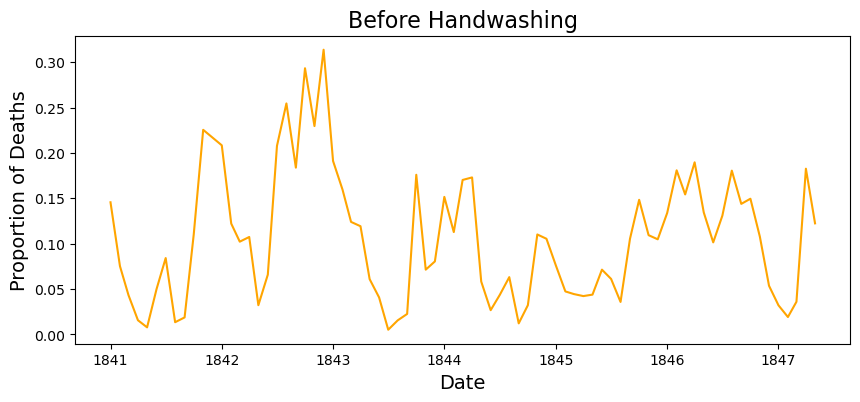

In [47]:
fig,ax = plt.subplots(figsize = (10,4))
x= before_washing["date"]
y= before_washing["proportion of Deaths"]
plt.plot(x, y, color= "orange")
plt.title("Before Handwashing", fontsize=16)
plt.xlabel("Date", fontsize = 14)
plt.ylabel("Proportion of Deaths", fontsize=14)

Text(0, 0.5, 'Proportion of Deaths')

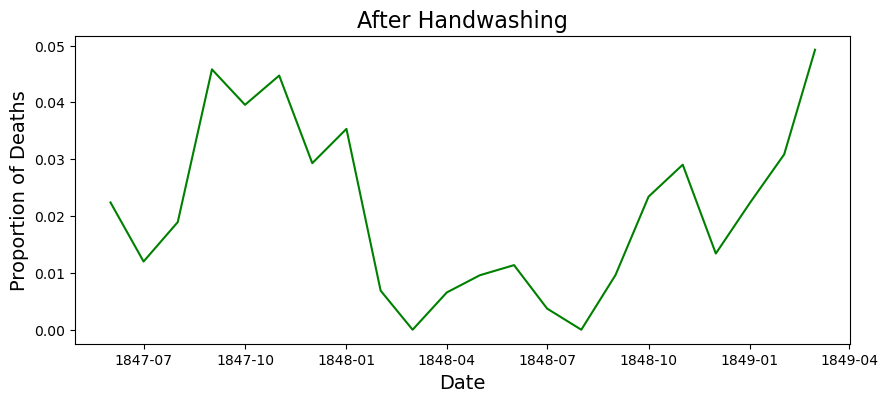

In [49]:
fig,ax = plt.subplots(figsize = (10,4))
x = after_washing["date"]
y = after_washing["proportion of Deaths"]
plt.plot(x, y, color= "green")
plt.title("After Handwashing", fontsize=16)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Proportion of Deaths", fontsize=14)

<Axes: xlabel='date', ylabel='Proportion of deaths'>

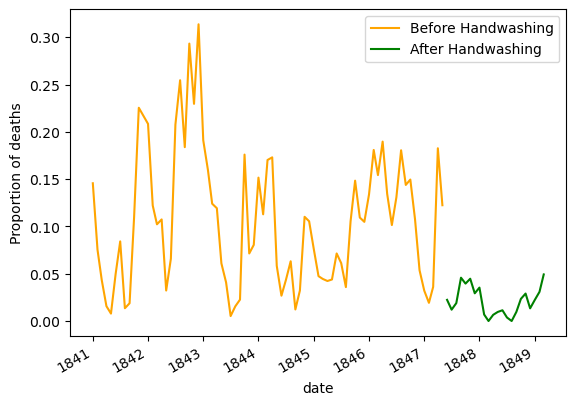

In [51]:
ax = before_washing.plot(x= "date", y= "proportion of Deaths", label= "Before Handwashing", color="orange")
after_washing.plot(x= "date", y= "proportion of Deaths", label= "After Handwashing", ax=ax, ylabel= "Proportion of deaths", color="green")

In [ ]:
After Comparison it's clear that a major downfall has been noticed after handwashing

In [53]:
#Let's calculate excatly how much did handwashing decreased the proportion of deaths on average
before_proportion = before_washing["proportion of Deaths"]
after_proportion = after_washing["proportion of Deaths"]
before_proportion.mean()


np.float64(0.10504998260908789)

In [54]:
after_proportion.mean()

np.float64(0.021093375097254535)

In [56]:
#calculate the difference between both proportions
mean_diff = after_proportion.mean() - before_proportion.mean()
mean_diff

np.float64(-0.08395660751183336)

In [ ]:
When we see this in form of percentage its a 8% of clear drop which has been happen after the initiative of Handwashing